In [ ]:
!pip install -q \
  transformers \
  datasets \
  evaluate \
  sentencepiece \
  accelerate \
  rouge_score \
  bert-score \
  nltk \
  safetensors \
  pypdf \
  gradio \
  sentence-transformers \
  protobuf==5.29.5
import os
os.kill(os.getpid(), 9)


## 2) Imports

In [1]:
import os
import re
import json
import math
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed
)

import evaluate
import nltk

warnings.filterwarnings("ignore")

#METEOR
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 3) Google Drive

In [3]:
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted successfully.")
    except Exception as e:
        print("Google Drive لم يتم ربطه. سيتم الحفظ محليًا فقط.")
        print("Reason:", e)
        USE_GOOGLE_DRIVE = False

Mounted at /content/drive
Google Drive mounted successfully.


## 4) Project Settings

In [4]:
class CFG:
    MODEL_NAME = "UBC-NLP/AraT5v2-base-1024"

    DATASET_NAME = "karimraouf/Arabic-Summarization-Dataset-AsDs"
    ARTICLE_COL = "article"
    SUMMARY_COL = "summary"

    MAX_INPUT_LENGTH = 1024
    MAX_TARGET_LENGTH = 128

    SEED = 42

    # التدريب
    NUM_EPOCHS = 15
    LEARNING_RATE = 3e-5
    TRAIN_BATCH_SIZE = 2
    EVAL_BATCH_SIZE = 2
    GRADIENT_ACCUMULATION_STEPS = 4
    WEIGHT_DECAY = 0.01
    EARLY_STOPPING_PATIENCE = 2

    # التوليد
    NUM_BEAMS = 4
    MIN_SUMMARY_LENGTH = 15
    MAX_SUMMARY_LENGTH = 128
    LENGTH_PENALTY = 1.0
    NO_REPEAT_NGRAM_SIZE = 3

    # chunking
    CHUNK_TOKEN_SIZE = 850
    CHUNK_OVERLAP = 80
    MAX_HIERARCHICAL_ROUNDS = 3

    FORCE_RETRAIN = False
    NUM_SHOWCASE_EXAMPLES = 5

    SENTENCE_EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

if USE_GOOGLE_DRIVE:
    PROJECT_DIR = Path("/content/drive/MyDrive/arabic_summarization_project")
else:
    PROJECT_DIR = Path("./arabic_summarization_project")

MODEL_DIR = PROJECT_DIR / "saved_model"
RESULTS_DIR = PROJECT_DIR / "results"
PLOTS_DIR = PROJECT_DIR / "plots"
PREDICTIONS_DIR = PROJECT_DIR / "predictions"

for d in [PROJECT_DIR, MODEL_DIR, RESULTS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Model directory:", MODEL_DIR)

Project directory: /content/drive/MyDrive/arabic_summarization_project
Model directory: /content/drive/MyDrive/arabic_summarization_project/saved_model


## 5) Data Upload

In [5]:
raw_dataset = load_dataset(CFG.DATASET_NAME)

print(raw_dataset)
print("\nExample:")
print(raw_dataset[list(raw_dataset.keys())[0]][0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-0e6e9af3a88227(…):   0%|          | 0.00/3.47M [00:00<?, ?B/s]

data/validation-00000-of-00001-9eb13f38d(…):   0%|          | 0.00/441k [00:00<?, ?B/s]

data/test-00000-of-00001-bffbaf820797229(…):   0%|          | 0.00/441k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2075 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/259 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/260 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 259
    })
    test: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 260
    })
})

Example:
{'title': 'السريالية: رحلة إلى أعماق العقل الباطن والأحلام', 'article': "السريالية هي حركة ثقافية وفنية انطلقت في باريس في أوائل عشرينيات القرن الماضي، وكان الشاعر أندريه بريتون هو منظرها الرئيسي. تأثرت الحركة بشدة بنظريات سيغموند فرويد حول العقل الباطن والأحلام، وسعت إلى تحرير الفكر والخيال من قيود العقل والمنطق والعادات المجتمعية. الهدف كان الوصول إلى 'واقع فائق' (sur-reality) من خلال دمج عالم الأحلام وعالم اليقظة. استخدم الفنانون والكتاب السرياليون تقنيات مختلفة لإطلاق العنان لعقلهم الباطن. من أشهر هذه التقنيات 'الكتابة الآلية' (Automatism)، حيث يتم الكتابة أو الرسم بسرعة دون تفكير واعٍ. كما استخدموا تقنية تجميع الأشياء غير الم

## 6) Train / Validation / Test

In [6]:
def prepare_dataset_splits(raw_dataset):

    keys = set(raw_dataset.keys())

    if {"train", "validation", "test"}.issubset(keys):
        print("الداتا تحتوي تقسيم جاهز: train / validation / test")
        return DatasetDict({
            "train": raw_dataset["train"],
            "validation": raw_dataset["validation"],
            "test": raw_dataset["test"],
        })

    if "train" in keys:
        print("الداتا تحتوي train فقط، سيتم التقسيم إلى 80/10/10.")
        dataset = raw_dataset["train"]

        split_1 = dataset.train_test_split(test_size=0.2, seed=CFG.SEED)
        train_dataset = split_1["train"]
        temp_dataset = split_1["test"]

        split_2 = temp_dataset.train_test_split(test_size=0.5, seed=CFG.SEED)
        validation_dataset = split_2["train"]
        test_dataset = split_2["test"]

        return DatasetDict({
            "train": train_dataset,
            "validation": validation_dataset,
            "test": test_dataset,
        })

    raise ValueError("لم أجد split مناسب في الداتا.")


dataset = prepare_dataset_splits(raw_dataset)

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

الداتا تحتوي تقسيم جاهز: train / validation / test
DatasetDict({
    train: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 259
    })
    test: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 260
    })
})
Train size: 2075
Validation size: 259
Test size: 260


## 7) Download Tokenizer and Base Model

In [7]:
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME, use_fast=False)

model_exists = (MODEL_DIR / "config.json").exists()

if model_exists and not CFG.FORCE_RETRAIN:
    print("تم العثور على نموذج محفوظ. سيتم تحميله بدل إعادة التدريب.")
    model = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIR)).to(device)
else:
    print("لا يوجد نموذج محفوظ أو FORCE_RETRAIN=True. سيتم تحميل النموذج الأساسي للتدريب.")
    model = AutoModelForSeq2SeqLM.from_pretrained(CFG.MODEL_NAME).to(device)
model.resize_token_embeddings(len(tokenizer))
print("Model loaded.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/2.35M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


...

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Model loaded.


## 8) preprocessing و tokenization

In [8]:
def clean_arabic_text(text):

    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = text.strip()
    return text


def preprocess_function(examples):
    articles = [clean_arabic_text(x) for x in examples[CFG.ARTICLE_COL]]
    summaries = [clean_arabic_text(x) for x in examples[CFG.SUMMARY_COL]]

    model_inputs = tokenizer(
        articles,
        max_length=CFG.MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=summaries,
        max_length=CFG.MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


remove_columns = dataset["train"].column_names

tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=remove_columns
)

tokenized_train = tokenized_dataset["train"]
tokenized_validation = tokenized_dataset["validation"]
tokenized_test = tokenized_dataset["test"]

print(tokenized_dataset)

Map:   0%|          | 0/2075 [00:00<?, ? examples/s]

Map:   0%|          | 0/259 [00:00<?, ? examples/s]

Map:   0%|          | 0/260 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 259
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 260
    })
})


## 9) ROUGE

In [11]:
rouge_metric = evaluate.load("rouge")

def compute_rouge_metrics(eval_pred):

    preds, labels = eval_pred

    if isinstance(preds, tuple):
        preds = preds[0]

    # Filter out invalid token IDs from predictions before decoding.
    # Replace any token ID that is negative or >= tokenizer.vocab_size with tokenizer.pad_token_id.
    # This handles potential out-of-range IDs that can occur during generation.
    preds_filtered = np.where(
        (preds >= 0) & (preds < tokenizer.vocab_size),
        preds,
        tokenizer.pad_token_id
    )

    decoded_preds = tokenizer.batch_decode(preds_filtered, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )

    return {
        "rouge1": round(result["rouge1"], 4),
        "rouge2": round(result["rouge2"], 4),
        "rougeL": round(result["rougeL"], 4),
    }

## 10) Training or downloading the saved form

In [12]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(RESULTS_DIR / "checkpoints"),

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=CFG.EVAL_BATCH_SIZE,
    gradient_accumulation_steps=CFG.GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=CFG.NUM_EPOCHS,
    weight_decay=CFG.WEIGHT_DECAY,

    predict_with_generate=True,
    generation_max_length=CFG.MAX_SUMMARY_LENGTH,
    generation_num_beams=CFG.NUM_BEAMS,

    fp16=torch.cuda.is_available(),
    report_to="none",

    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_rougeL",
    greater_is_better=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_rouge_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CFG.EARLY_STOPPING_PATIENCE)],
)

if model_exists and not CFG.FORCE_RETRAIN:
    print("تم تحميل النموذج المحفوظ. لن تتم إعادة التدريب.")
else:
    print("بدء التدريب...")
    train_result = trainer.train()

    print("حفظ النموذج النهائي...")
    trainer.save_model(str(MODEL_DIR))
    tokenizer.save_pretrained(str(MODEL_DIR))

    train_metrics = train_result.metrics
    with open(RESULTS_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
        json.dump(train_metrics, f, ensure_ascii=False, indent=2)

    print("تم حفظ النموذج في:", MODEL_DIR)

بدء التدريب...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,2.872500,1.882106,0.050200,0.011600,0.049200
2,2.472900,1.747172,0.055200,0.008800,0.054100
3,2.324600,1.672834,0.046100,0.011600,0.044200
4,2.172000,1.632997,0.044500,0.007700,0.044800


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


حفظ النموذج النهائي...
تم حفظ النموذج في: /content/drive/MyDrive/arabic_summarization_project/saved_model


## 11) Download the final reasoning template

In [13]:
tokenizer_inf = AutoTokenizer.from_pretrained(str(MODEL_DIR), use_fast=False)
model_inf = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIR)).to(device)
model_inf.eval()

print("Inference model loaded from:", MODEL_DIR)

Inference model loaded from: /content/drive/MyDrive/arabic_summarization_project/saved_model


## 12) plot Loss

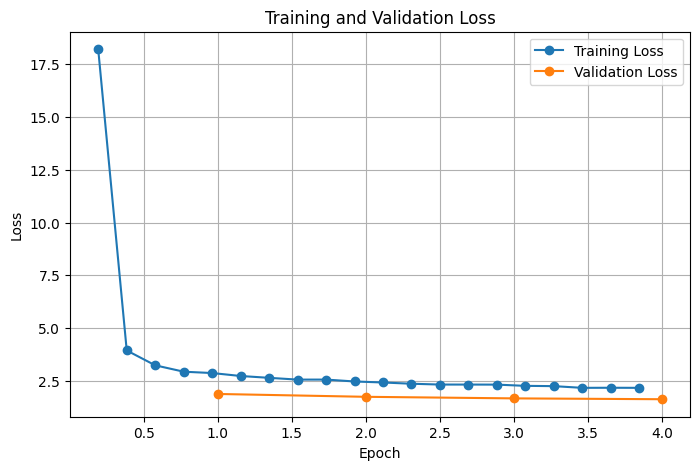

Loss plot path: /content/drive/MyDrive/arabic_summarization_project/plots/training_validation_loss.png


In [14]:
def plot_training_curves(trainer, save_path=None):
    logs = trainer.state.log_history

    train_epochs, train_losses = [], []
    eval_epochs, eval_losses = [], []

    for log in logs:
        if "loss" in log and "epoch" in log:
            train_epochs.append(log["epoch"])
            train_losses.append(log["loss"])

        if "eval_loss" in log and "epoch" in log:
            eval_epochs.append(log["epoch"])
            eval_losses.append(log["eval_loss"])

    if len(train_losses) == 0 and len(eval_losses) == 0:
        print("لا توجد سجلات loss للرسم. ربما تم تحميل نموذج محفوظ بدون تدريب في هذه الجلسة.")
        return

    plt.figure(figsize=(8, 5))

    if train_losses:
        plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")

    if eval_losses:
        plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


loss_plot_path = PLOTS_DIR / "training_validation_loss.png"
plot_training_curves(trainer, save_path=loss_plot_path)
print("Loss plot path:", loss_plot_path)

## 13) Function to summarize normal text

In [15]:
@torch.no_grad()
def summarize_text(
    text,
    min_length=CFG.MIN_SUMMARY_LENGTH,
    max_length=CFG.MAX_SUMMARY_LENGTH,
    num_beams=CFG.NUM_BEAMS
):
    text = clean_arabic_text(text)

    if not text:
        return ""

    inputs = tokenizer_inf(
        text,
        return_tensors="pt",
        max_length=CFG.MAX_INPUT_LENGTH,
        truncation=True,
        padding=True
    ).to(device)

    summary_ids = model_inf.generate(
        **inputs,
        min_length=min_length,
        max_length=max_length,
        num_beams=num_beams,
        length_penalty=CFG.LENGTH_PENALTY,
        no_repeat_ngram_size=CFG.NO_REPEAT_NGRAM_SIZE,
        early_stopping=True
    )

    summary = tokenizer_inf.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    return clean_arabic_text(summary)

## 14) Chunking

In [16]:
def split_text_by_tokens(text, chunk_token_size=CFG.CHUNK_TOKEN_SIZE, overlap=CFG.CHUNK_OVERLAP):

    text = clean_arabic_text(text)
    token_ids = tokenizer_inf.encode(text, add_special_tokens=False)

    if len(token_ids) <= chunk_token_size:
        return [text]

    chunks = []
    start = 0

    while start < len(token_ids):
        end = start + chunk_token_size
        chunk_ids = token_ids[start:end]
        chunk_text = tokenizer_inf.decode(chunk_ids, skip_special_tokens=True).strip()

        if chunk_text:
            chunks.append(chunk_text)

        if end >= len(token_ids):
            break

        start = max(0, end - overlap)

    return chunks


def summarize_long_text(text, max_rounds=CFG.MAX_HIERARCHICAL_ROUNDS):
    """
    hierarchical summarization:
    1. chunks.
    2. summarize chunk.
    3. ++
    4. resummarize if text stell
    """
    text = clean_arabic_text(text)

    if not text:
        return ""

    chunks = split_text_by_tokens(text)

    if len(chunks) == 1:
        return summarize_text(chunks[0])

    partial_summaries = []
    for i, chunk in enumerate(chunks, start=1):
        print(f"تلخيص chunk {i}/{len(chunks)}")
        partial_summaries.append(summarize_text(chunk))

    combined_summary = " ".join(partial_summaries).strip()

    round_idx = 1
    while round_idx <= max_rounds:
        combined_token_len = len(tokenizer_inf.encode(combined_summary, add_special_tokens=False))

        if combined_token_len <= CFG.CHUNK_TOKEN_SIZE:
            return summarize_text(combined_summary)

        print(f"إعادة تلخيص هرمي - الجولة {round_idx}")
        chunks = split_text_by_tokens(combined_summary)
        partial_summaries = [summarize_text(chunk) for chunk in chunks]
        combined_summary = " ".join(partial_summaries).strip()

        round_idx += 1

    return combined_summary

## 15) PDF

In [ ]:
from pypdf import PdfReader

def extract_text_from_pdf(pdf_path):

    reader = PdfReader(pdf_path)
    pages_text = []

    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            pages_text.append(page_text)

    full_text = "\n".join(pages_text)
    return clean_arabic_text(full_text)


def summarize_pdf(pdf_path):

    pdf_text = extract_text_from_pdf(pdf_path)

    if not pdf_text:
        return "لم يتم استخراج نص من ملف PDF. قد يكون الملف ممسوحًا ضوئيًا scanned PDF."

    return summarize_long_text(pdf_text)

## 16) Final assessment on the Test Set using the seven metrics

In [17]:
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
chrf_metric = evaluate.load("chrf")
bertscore_metric = evaluate.load("bertscore")


def generate_predictions(dataset_split, max_examples=None):

    if max_examples is not None:
        dataset_split = dataset_split.select(range(min(max_examples, len(dataset_split))))

    sources = [clean_arabic_text(x) for x in dataset_split[CFG.ARTICLE_COL]]
    references = [clean_arabic_text(x) for x in dataset_split[CFG.SUMMARY_COL]]

    predictions = []

    for i, src in enumerate(sources, start=1):
        print(f"Generating summary {i}/{len(sources)}")

        token_len = len(tokenizer_inf.encode(src, add_special_tokens=False))

        if token_len > CFG.MAX_INPUT_LENGTH:
            predictions.append(summarize_long_text(src))
        else:
            predictions.append(summarize_text(src))

    return sources, predictions, references


def compute_semantic_similarity(predictions, references):

    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim

    emb_model = SentenceTransformer(CFG.SENTENCE_EMBEDDING_MODEL)

    pred_emb = emb_model.encode(
        predictions,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    ref_emb = emb_model.encode(
        references,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    sims = cos_sim(pred_emb, ref_emb).diagonal()
    return float(sims.mean().cpu().item())


def compute_all_generation_metrics(sources, predictions, references):
    """
    1. ROUGE-1
    2. ROUGE-2
    3. ROUGE-L
    4. BERTScore
    5. METEOR
    6. chrF
    7. Semantic Similarity
    """
    rouge_result = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False
    )

    bertscore_result = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="ar",
        rescale_with_baseline=False
    )

    meteor_result = meteor_metric.compute(
        predictions=predictions,
        references=references
    )

    chrf_result = chrf_metric.compute(
        predictions=predictions,
        references=references
    )

    semantic_sim = compute_semantic_similarity(predictions, references)

    results = {
        "ROUGE-1": round(rouge_result["rouge1"] * 100, 4),
        "ROUGE-2": round(rouge_result["rouge2"] * 100, 4),
        "ROUGE-L": round(rouge_result["rougeL"] * 100, 4),
        "BERTScore": round(float(np.mean(bertscore_result["f1"])) * 100, 4),
        "METEOR": round(meteor_result["meteor"] * 100, 4),
        "chrF": round(chrf_result["score"], 4),
        "Semantic Similarity": round(semantic_sim * 100, 4),
    }

    return results

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 17) Run the final evaluation and save the results.

In [18]:
QUICK_EVAL_MAX_EXAMPLES = 20

quick_sources, quick_predictions, quick_references = generate_predictions(
    dataset["test"],
    max_examples=QUICK_EVAL_MAX_EXAMPLES
)

quick_metrics = compute_all_generation_metrics(
    quick_sources,
    quick_predictions,
    quick_references
)

print("\nQuick Eval Metrics:")
for k, v in quick_metrics.items():
    print(f"{k}: {v}")

Generating summary 1/20
Generating summary 2/20
Generating summary 3/20
Generating summary 4/20
Generating summary 5/20
Generating summary 6/20
Generating summary 7/20
Generating summary 8/20
Generating summary 9/20
Generating summary 10/20
Generating summary 11/20
Generating summary 12/20
Generating summary 13/20
Generating summary 14/20
Generating summary 15/20
Generating summary 16/20
Generating summary 17/20
Generating summary 18/20
Generating summary 19/20
Generating summary 20/20


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Quick Eval Metrics:
ROUGE-1: 10.0
ROUGE-2: 0.0
ROUGE-L: 10.0
BERTScore: 78.0073
METEOR: 26.7021
chrF: 39.8323
Semantic Similarity: 82.6873


In [19]:

EVAL_MAX_EXAMPLES = None

test_sources, test_predictions, test_references = generate_predictions(
    dataset["test"],
    max_examples=EVAL_MAX_EXAMPLES
)

final_metrics = compute_all_generation_metrics(
    test_sources,
    test_predictions,
    test_references
)

print("\nFinal Test Metrics:")
for k, v in final_metrics.items():
    print(f"{k}: {v}")

metrics_path = RESULTS_DIR / "final_test_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=2)

predictions_df = pd.DataFrame({
    "article": test_sources,
    "reference_summary": test_references,
    "generated_summary": test_predictions,
})

predictions_path = PREDICTIONS_DIR / "test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")

print("\nSaved metrics to:", metrics_path)
print("Saved predictions to:", predictions_path)

Generating summary 1/260
Generating summary 2/260
Generating summary 3/260
Generating summary 4/260
Generating summary 5/260
Generating summary 6/260
Generating summary 7/260
Generating summary 8/260
Generating summary 9/260
Generating summary 10/260
Generating summary 11/260
Generating summary 12/260
Generating summary 13/260
Generating summary 14/260
Generating summary 15/260
Generating summary 16/260
Generating summary 17/260
Generating summary 18/260
Generating summary 19/260
Generating summary 20/260
Generating summary 21/260
Generating summary 22/260
Generating summary 23/260
Generating summary 24/260
Generating summary 25/260
Generating summary 26/260
Generating summary 27/260
Generating summary 28/260
Generating summary 29/260
Generating summary 30/260
Generating summary 31/260
Generating summary 32/260
Generating summary 33/260
Generating summary 34/260
Generating summary 35/260
Generating summary 36/260
Generating summary 37/260
Generating summary 38/260
Generating summary 39

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Final Test Metrics:
ROUGE-1: 7.4982
ROUGE-2: 0.3846
ROUGE-L: 7.5458
BERTScore: 77.7619
METEOR: 26.8728
chrF: 39.6919
Semantic Similarity: 83.524

Saved metrics to: /content/drive/MyDrive/arabic_summarization_project/results/final_test_metrics.json
Saved predictions to: /content/drive/MyDrive/arabic_summarization_project/predictions/test_predictions.csv


## 18) plot

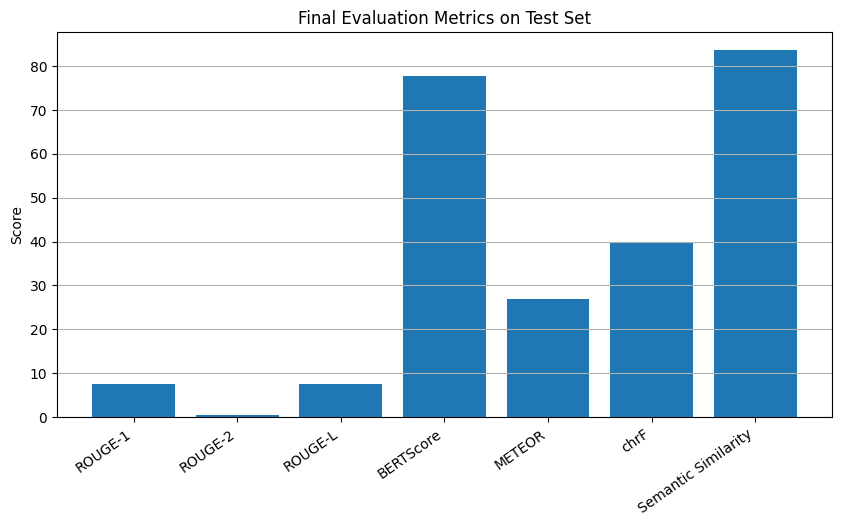

Metrics plot path: /content/drive/MyDrive/arabic_summarization_project/plots/final_metrics_bar.png


In [23]:
def plot_metrics_bar(metrics_dict, save_path=None):
    names = list(metrics_dict.keys())
    values = list(metrics_dict.values())

    plt.figure(figsize=(10, 5))
    plt.bar(names, values)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Score")
    plt.title("Final Evaluation Metrics on Test Set")
    plt.grid(axis="y")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


metrics_plot_path = PLOTS_DIR / "final_metrics_bar.png"
plot_metrics_bar(final_metrics, save_path=metrics_plot_path)
print("Metrics plot path:", metrics_plot_path)

## 19) Multiple test examples

In [20]:
def evaluate_showcase_examples(num_examples=CFG.NUM_SHOWCASE_EXAMPLES):

    sample = dataset["test"].select(range(min(num_examples, len(dataset["test"]))))

    rows = []
    for i, item in enumerate(sample, start=1):
        article = clean_arabic_text(item[CFG.ARTICLE_COL])
        reference = clean_arabic_text(item[CFG.SUMMARY_COL])
        generated = summarize_text(article)

        rows.append({
            "example_id": i,
            "article": article,
            "reference_summary": reference,
            "generated_summary": generated,
        })

        print("=" * 80)
        print(f"Example {i}")
        print("\nOriginal Article:")
        print(article[:1000] + ("..." if len(article) > 1000 else ""))
        print("\nReference Summary:")
        print(reference)
        print("\nGenerated Summary:")
        print(generated)

    df = pd.DataFrame(rows)
    path = PREDICTIONS_DIR / "showcase_examples.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("\nSaved showcase examples to:", path)

    return df


showcase_df = evaluate_showcase_examples()
showcase_df.head()

Example 1

Original Article:
يعد علاء الدين أبو الحسن علي بن أبي الحزم القرشي الدمشقي، المعروف بابن النفيس، واحداً من أعظم الأطباء في تاريخ الطب، وهو شخصية علمية فذة من القرن الثالث عشر الميلادي. على الرغم من شهرة ويليام هارفي في الغرب بأنه مكتشف الدورة الدموية، إلا أن ابن النفيس سبقه بأكثر من ثلاثة قرون في تقديم أول وصف علمي دقيق لـ"الدورة الدموية الصغرى" (الرئوية). في ذلك الوقت، كانت النظرية السائدة هي نظرية جالينوس، التي كانت تقول إن الدم ينتقل من الجانب الأيمن للقلب إلى الجانب الأيسر عبر مسام غير مرئية في الحاجز الفاصل بينهما. لكن ابن النفيس، من خلال دراسته التشريحية الدقيقة وتفكيره النقدي، رفض هذه النظرية لعدم وجود دليل مادي عليها. في كتابه "شرح تشريح القانون لابن سينا"، قدم ابن النفيس نظريته الثورية، حيث شرح بوضوح أن الدم يخرج من البطين الأيمن للقلب إلى الرئتين عبر الشريان الرئوي، وهناك يمتزج بالهواء، ثم يعود إلى البطين الأيسر للقلب عبر الوريد الرئوي ليكون جاهزاً للتوزيع على باقي الجسم. كان هذا الوصف هو الأول من نوعه في التاريخ الذي يحدد بشكل صحيح وظيفة الرئتين في تنقية الدم. للأ

,example_id,article,reference_summary,generated_summary
0,1,يعد علاء الدين أبو الحسن علي بن أبي الحزم القر...,ابن النفيس، الطبيب الدمشقي من القرن الثالث عشر...,يشرح المقال تاريخ الطبيب علاء الدين علي بن أبي...
1,2,تعتبر المواد البلاستيكية اختراعًا عجيبًا، لكنه...,يسلط المقال الضوء على أزمة التلوث البلاستيكي ا...,يشرح المقال كيف تحولت المواد البلاستيكية إلى ك...
2,3,على الرغم من أن الحضارات القديمة استخدمت مواد ...,يعود اختراع الورق الحقيقي إلى الصين في القرن ا...,يشرح المقال تاريخ اختراع الورق الحقيقي، مشيراً...
3,4,القهوة، ذلك المشروب الأسود العطري الذي لا غنى ...,يتتبع المقال بالتفصيل التاريخ المثير للقهوة، ب...,يشرح المقال تاريخ القهوة، موضحًا كيف انتقلت من...
4,5,يعتبر جان جاك روسو (1712-1778) أحد أكثر مفكري ...,تشرح المقالة بالتفصيل فلسفة جان جاك روسو السيا...,يشرح المقال مفهوم 'العقد الاجتماعي' لجان جاك ر...


## 20) summarizing a normal text

In [21]:
test_text = """
إن التكنولوجيا أصبحت جزءًا أساسيًا من حياة الإنسان المعاصر، حيث تدخل في التعليم والصحة والاتصالات والعمل.
وقد ساهمت التقنيات الحديثة في تسهيل الوصول إلى المعلومات وتطوير أساليب التعلم عن بعد، كما ساعدت في تحسين جودة الخدمات الطبية
من خلال أنظمة التشخيص الذكية وتخزين السجلات الصحية إلكترونيًا. ومع ذلك، فإن الاعتماد الكبير على التكنولوجيا يفرض تحديات جديدة
تتعلق بالخصوصية وأمن البيانات وتقليل التواصل المباشر بين الأفراد.
"""

summary = summarize_text(test_text)
print(summary)

يشرح المقال كيف أن التكنولوجيا أصبحت جزءًا أساسيًا من حياة الإنسان المعاصر، حيث تدخل في التعليم والصحة والاتصالات. ويخلص إلى أن الاعتماد الكبير على التكنولوجيا يفرض تحديات جديدة تتعلق بالخصوصية وأمن البيانات.


## 21) summarizing a long text

In [22]:
long_text = test_text * 20

long_summary = summarize_long_text(long_text)
print(long_summary)

Token indices sequence length is longer than the specified maximum sequence length for this model (1540 > 1024). Running this sequence through the model will result in indexing errors


تلخيص chunk 1/2
تلخيص chunk 2/2
يشرح المقال أن التكنولوجيا أصبحت جزءًا أساسيًا من حياة الإنسان المعاصر، حيث تدخل في التعليم والصحة والاتصالات والعمل. وقد ساهمت التقنيات الحديثة في تسهيل الوصول إلى المعلومات وتطوير أساليب التعلم عن بعد وتحسين جودة الخدمات الطبية من خلال أنظمة التشخيص الذكية وتخزين السجلات الصحية إلكترونيًا. ومع ذلك، فإن الاعتماد الكبير على التكنولوجيا يفرض تحديات جديدة تتعلق بالخصوصية وأمن البيانات وتقليل التواصل المباشر بين الأفراد.


## 22)Gradio

In [24]:
import gradio as gr

def gradio_summarize_text(text):
    if text is None or len(text.strip()) == 0:
        return "يرجى إدخال نص عربي."
    return summarize_long_text(text)


def gradio_summarize_pdf(file):
    if file is None:
        return "يرجى رفع ملف PDF."

    pdf_path = file if isinstance(file, str) else file.name
    return summarize_pdf(pdf_path)


with gr.Blocks(title="Arabic Text Summarization Assistant") as demo:
    gr.Markdown("# Smart Assistant for Summarizing Arabic Texts")
    gr.Markdown("مساعد بسيط لتلخيص النصوص العربية وملفات PDF النصية باستخدام نموذج AraT5.")

    with gr.Tab("تلخيص نص"):
        text_input = gr.Textbox(
            label="أدخل النص العربي",
            lines=12,
            placeholder="اكتب أو الصق النص العربي هنا..."
        )
        text_button = gr.Button("تلخيص النص")
        text_output = gr.Textbox(label="الملخص", lines=8)

        text_button.click(
            fn=gradio_summarize_text,
            inputs=text_input,
            outputs=text_output
        )

    with gr.Tab("تلخيص PDF"):
        pdf_input = gr.File(
            label="ارفع ملف PDF نصي",
            file_types=[".pdf"]
        )
        pdf_button = gr.Button("تلخيص PDF")
        pdf_output = gr.Textbox(label="ملخص PDF", lines=10)

        pdf_button.click(
            fn=gradio_summarize_pdf,
            inputs=pdf_input,
            outputs=pdf_output
        )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://309ecf822210a710c7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
